# Sideview glancing-incidence slice geometry

This notebook shows the sideview setup used for the Fresnel prototype: the tilted input beam, the atomic potential, and every sampled slice plane.

In [34]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from wide_angle_propagation.propagation_methods import (
    make_gaussian_atom_potential_sideview_1d,
    phase_grating_1d_from_projected_potential,
    simulate_glancing_fresnel_baseline_1d,
)

jax.config.update("jax_enable_x64", True)

## Geometry

In [35]:
energy = 30e3

# Physical sideview coordinates are (x, z): x is vertical, z is horizontal.
z_left = 0.0
z_right = 24.0
z_bounce = 0.5 * (z_left + z_right)
surface_x = 0.0
glancing_angle_degrees = 3.0
glancing_angle = jnp.deg2rad(glancing_angle_degrees)
input_beam_tilt = -glancing_angle
edge_height = jnp.tan(glancing_angle) * (z_right - z_left) / 2.0

# Slice sampling grid. u is the local transverse coordinate on each slice plane.
n_u = 384
du = 0.045
u = (jnp.arange(n_u) - n_u // 2) * du
beam_waist = 0.42

# Slice centers follow the central grazing path. The slice normals rotate at the bounce.
n_steps = 192
dz_view = (z_right - z_left) / n_steps
path_step = dz_view / jnp.cos(glancing_angle)
target_atom_u = 0.0
target_path_coordinate = 0.5 * n_steps * path_step
input_beam_center_u = target_atom_u - target_path_coordinate * jnp.tan(input_beam_tilt)
z_mid = z_left + (jnp.arange(n_steps) + 0.5) * dz_view
center_x_mid = surface_x + jnp.tan(glancing_angle) * jnp.abs(z_mid - z_bounce)
path_centers = jnp.stack([center_x_mid, z_mid], axis=1)

incoming_direction = jnp.array([jnp.sin(input_beam_tilt), jnp.cos(input_beam_tilt)])
outgoing_direction = jnp.array([jnp.sin(glancing_angle), jnp.cos(glancing_angle)])
directions = jnp.where(
    (z_mid < z_bounce)[:, None],
    incoming_direction[None, :],
    outgoing_direction[None, :],
)
transverse_dirs = jnp.stack([directions[:, 1], -directions[:, 0]], axis=1)
slice_points = path_centers[:, None, :] + u[None, :, None] * transverse_dirs[:, None, :]

input_center = jnp.array([edge_height, z_left])
bounce_center = jnp.array([surface_x, z_bounce])

float(jnp.rad2deg(input_beam_tilt)), slice_points.shape

(-3.0000000000000004, (192, 384, 2))

## Slice potential, atom phase, and Fresnel wavefronts

In [36]:
n_atoms = 24
atom_slice_indices = jnp.linspace(4, n_steps - 5, n_atoms).astype(jnp.int32)
atom_positions = path_centers[atom_slice_indices]
atom_strengths = 10000.0 * jnp.ones(n_atoms)
atom_sigmas = 0.18 * jnp.ones(n_atoms)

potential_slices = make_gaussian_atom_potential_sideview_1d(
    slice_points.reshape(-1, 2),
    atom_positions,
    atom_strengths,
    atom_sigmas,
).reshape(n_steps, n_u)
atom_phase_slices = jnp.angle(
    phase_grating_1d_from_projected_potential(potential_slices * path_step, energy)
)

input_wave = jnp.exp(-0.5 * ((u - input_beam_center_u) / beam_waist) ** 2).astype(jnp.complex128)
fresnel_wave, fresnel_farfield, fresnel_diag = simulate_glancing_fresnel_baseline_1d(
    input_wave,
    potential_slices,
    du,
    path_step,
    energy,
    input_tilt=input_beam_tilt,
)
wavefront_intensity = jnp.abs(fresnel_diag["wavefronts"]) ** 2

assert jnp.all(jnp.isfinite(wavefront_intensity))
assert jnp.all(jnp.isfinite(atom_phase_slices))

potential_slices.shape, wavefront_intensity.shape, atom_phase_slices.shape, atom_positions.shape

((192, 384), (192, 384), (192, 384), (24, 2))

## Slice-stack image


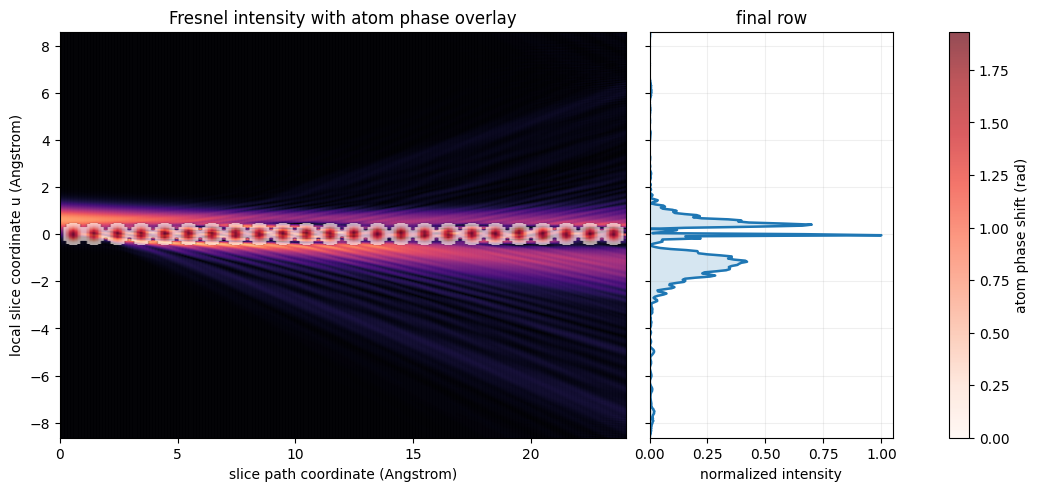

In [37]:
intensity = np.asarray(wavefront_intensity)
intensity_display = np.sqrt(intensity / (intensity.max() + 1e-30))
phase = np.asarray(atom_phase_slices)
phase_max = max(float(np.max(phase)), 1e-12)
phase_overlay = np.ma.masked_less(phase, 0.03 * phase_max)
output_intensity = np.asarray(jnp.abs(fresnel_wave) ** 2)
output_intensity = output_intensity / (output_intensity.max() + 1e-30)

slice_axis = np.arange(n_steps) * float(path_step)
extent = [
    float(slice_axis[0]),
    float(slice_axis[-1] + path_step),
    float(u[0]),
    float(u[-1]),
]

fig, (ax, ax_out) = plt.subplots(
    1,
    2,
    figsize=(12.6, 4.8),
    width_ratios=[4.0, 1.15],
    sharey=True,
    constrained_layout=True,
)
ax.imshow(
    intensity_display.T,
    extent=extent,
    origin="lower",
    aspect="equal",
    cmap="magma",
    vmin=0.0,
    vmax=1.0,
)
phase_plot = ax.imshow(
    phase_overlay.T,
    extent=extent,
    origin="lower",
    aspect="equal",
    cmap="Reds",
    alpha=0.70,
    vmin=0.0,
    vmax=phase_max,
)

# Thin vertical marks show the individual slice positions without remapping them into lab x-z space.
ax.vlines(slice_axis, float(u[0]), float(u[-1]), color="white", linewidth=0.12, alpha=0.18)

ax.set_xlabel("slice path coordinate (Angstrom)")
ax.set_ylabel("local slice coordinate u (Angstrom)")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Fresnel intensity with atom phase overlay")

ax_out.plot(output_intensity, np.asarray(u), color="tab:blue", lw=1.8)
ax_out.fill_betweenx(np.asarray(u), 0.0, output_intensity, color="tab:blue", alpha=0.18)
ax_out.set_xlabel("normalized intensity")
ax_out.set_title("final row")
ax_out.set_xlim(0.0, 1.05)
ax_out.grid(alpha=0.2)

fig.colorbar(phase_plot, ax=[ax, ax_out], label="atom phase shift (rad)")
plt.show()